In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [2]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = None
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [3]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "new_names_local_GRBafterglows_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/lustre/lrspec/us

[INFO] Loaded metric module: new_names_local_GRBafterglows_metric
[INFO] Loaded shared_utils module


In [18]:
#metric configurations
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = False 
generate_new_pop = False
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 1e-8

# apply None for non-use case 
z_min, z_max = .00226, .3
d_min, d_max = None, None #3000, 4000

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = False
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="GRBafterglows", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [19]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Loading light curve templates from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_templates.pkl.
Loaded GRB afterglow templates from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_templates.pkl


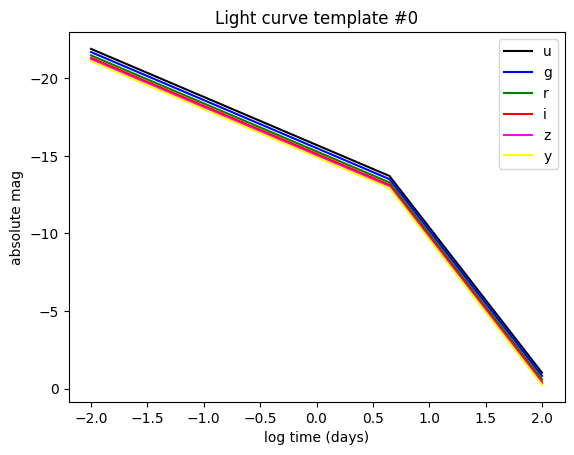

/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


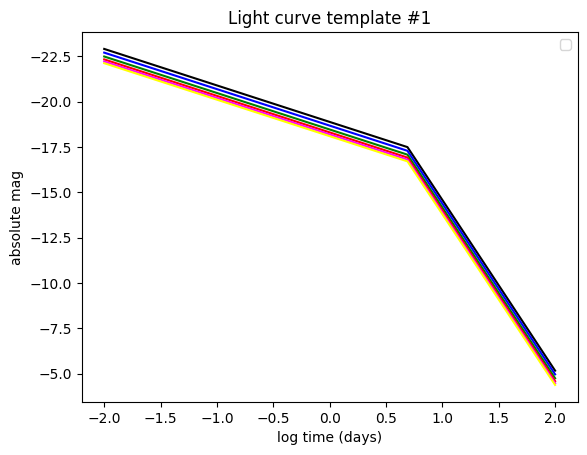

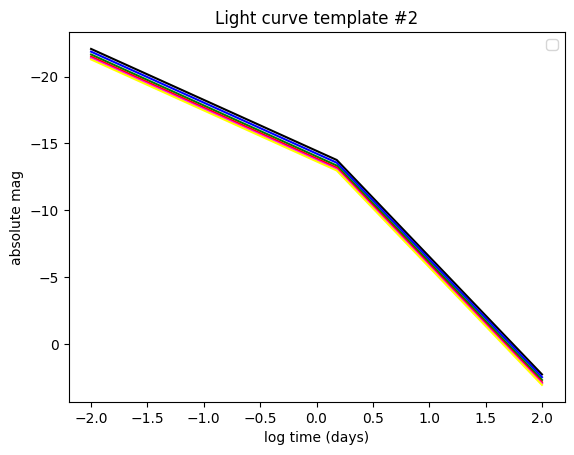

In [6]:
#plot light curves from pkl file if desired
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3)

In [20]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


[INFO] Loading population from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_population.pkl
Loaded population from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_population.pkl


## All 10 years


--- Running four_roll_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 754
mag_obs         | type: <class 'list'> | length: 754
snr_obs         | type: <class 'list'> | length: 754
filter          | type: <class 'list'> | length: 754
first_det_mjd   | type: <class 'numpy.float64'> | value: 64254.307854598235
last_det_mjd    | type: <class 'numpy.float64'> | value: 64264.24895395966
fade_time_days  | type: <class 'numpy.float64'> | value: 10.865975972672459
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 924
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 368.9850320054049
peak_mjd_observed | type: <class 'numpy.float64'> | value: 64254.307854598235
peak_mag_observed | type: <class 'numpy.float64'> 

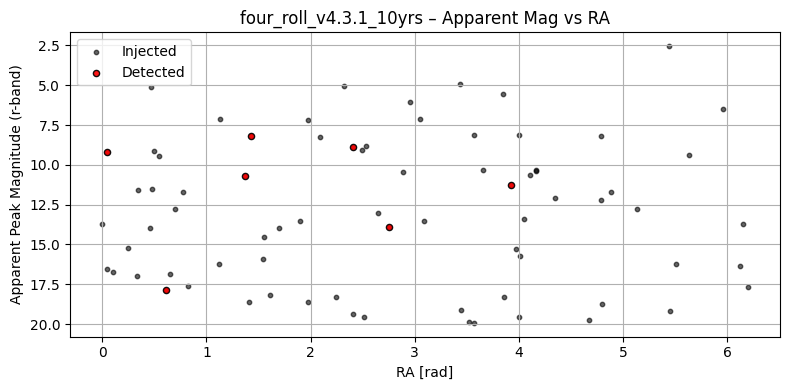

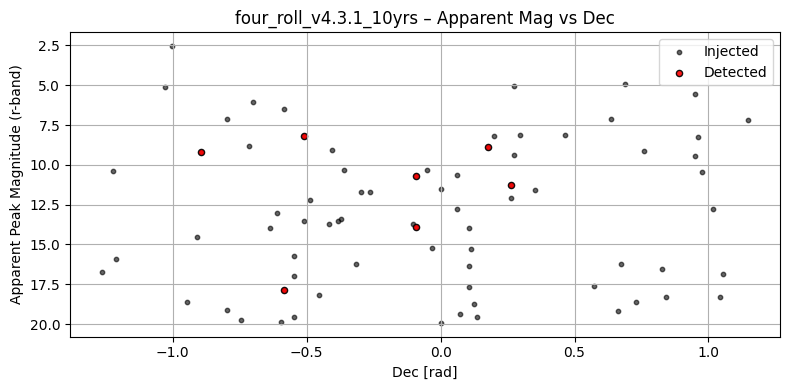

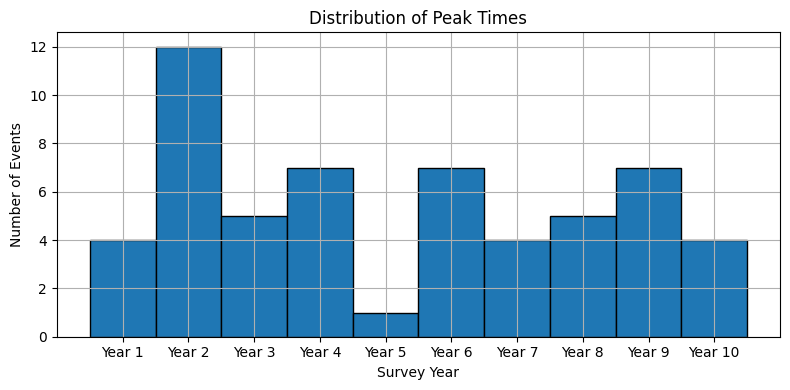

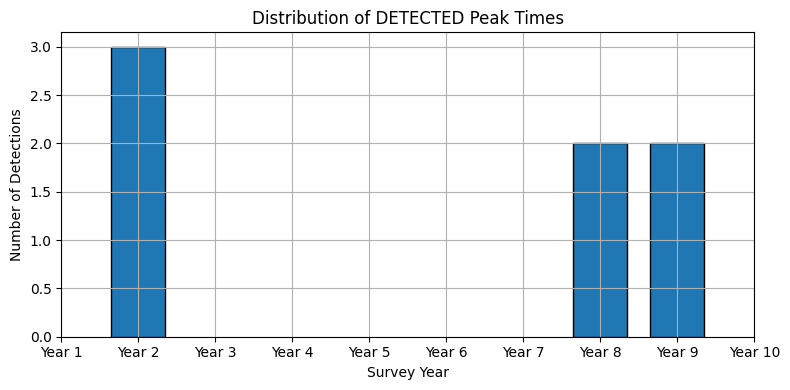

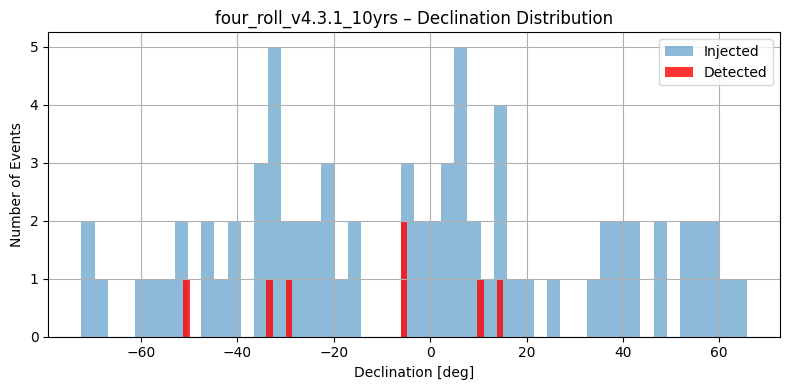


--- Running baseline_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 778
mag_obs         | type: <class 'list'> | length: 778
snr_obs         | type: <class 'list'> | length: 778
filter          | type: <class 'list'> | length: 778
first_det_mjd   | type: <class 'numpy.float64'> | value: 64263.264151230505
last_det_mjd    | type: <class 'numpy.float64'> | value: 64264.252103498584
fade_time_days  | type: <class 'numpy.float64'> | value: 10.869125511599123
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 924
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 368.9850320054049
peak_mjd_observed | type: <class 'numpy.float64'> | value: 64264.02497695032
peak_mag_observed | type: <class 'numpy.float64'> |

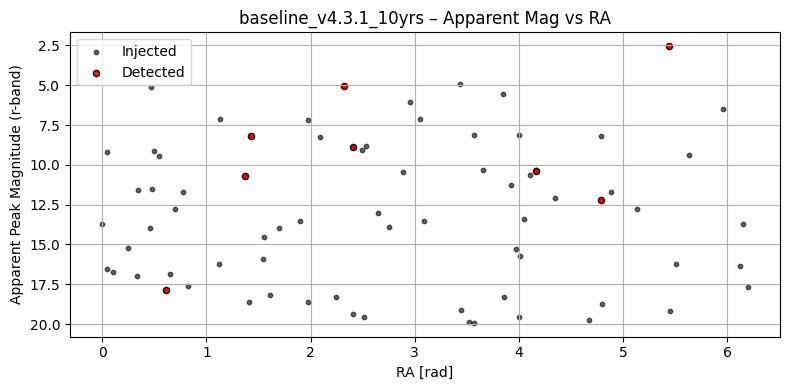

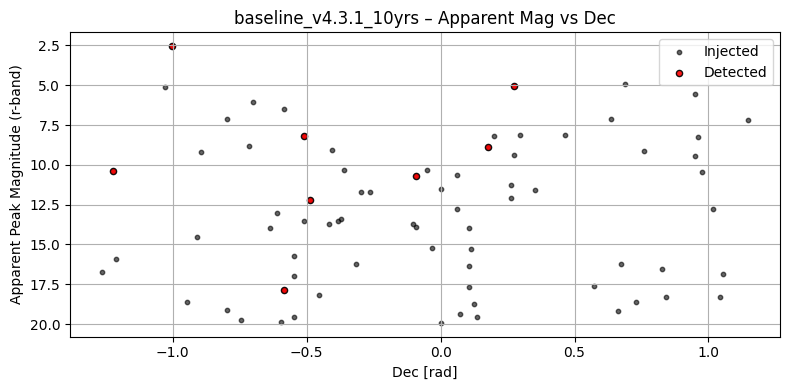

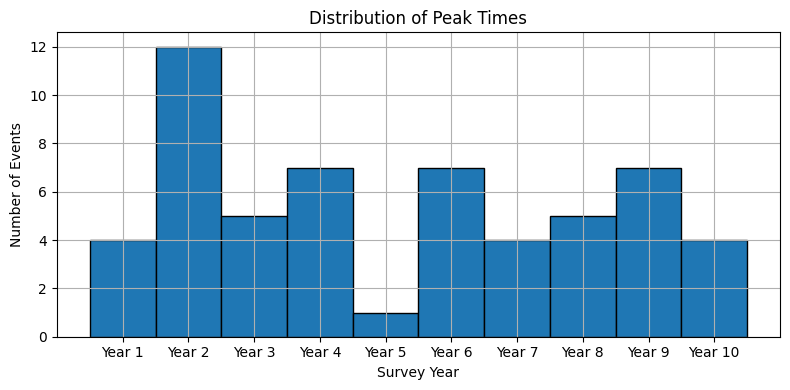

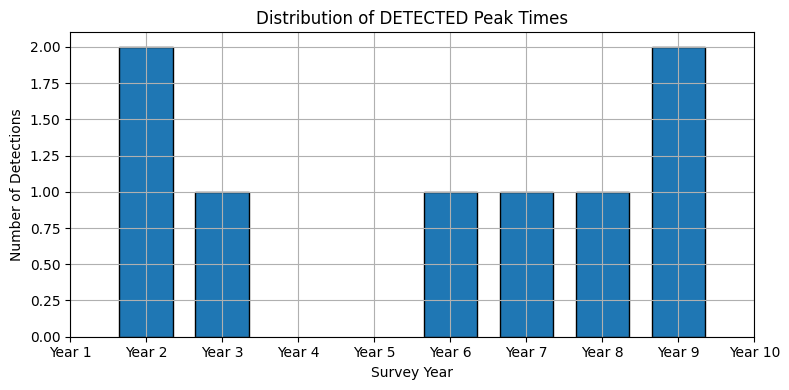

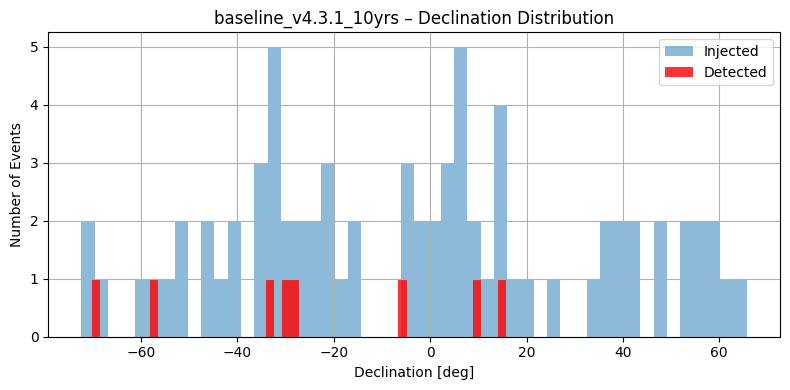


--- Running noroll_v3.6_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 747
mag_obs         | type: <class 'list'> | length: 747
snr_obs         | type: <class 'list'> | length: 747
filter          | type: <class 'list'> | length: 747
first_det_mjd   | type: <class 'numpy.float64'> | value: 64255.314686607264
last_det_mjd    | type: <class 'numpy.float64'> | value: 64255.338913347674
fade_time_days  | type: <class 'numpy.float64'> | value: 1.9559353606891818
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 924
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 368.9850320054049
peak_mjd_observed | type: <class 'numpy.float64'> | value: 64255.314686607264
peak_mag_observed | type: <class 'numpy.float64'> | va

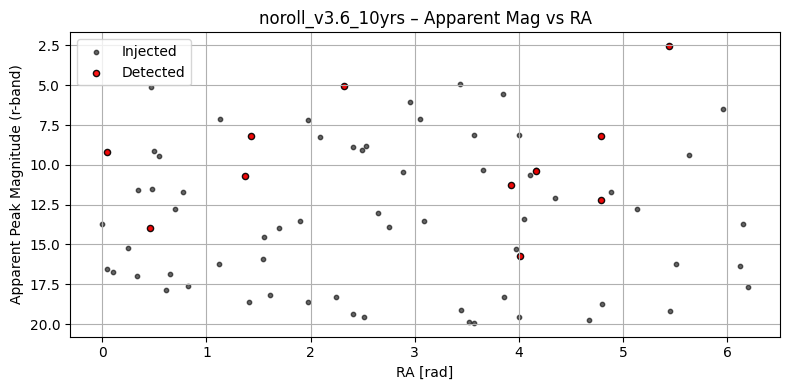

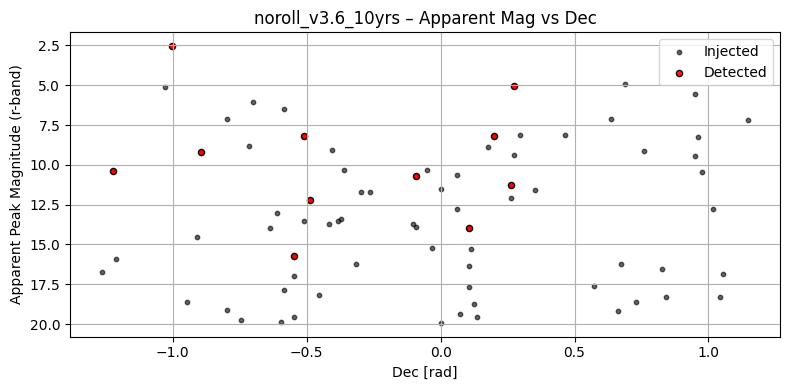

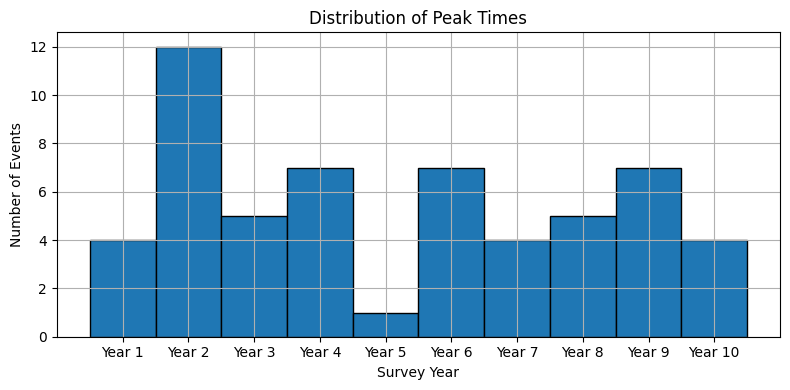

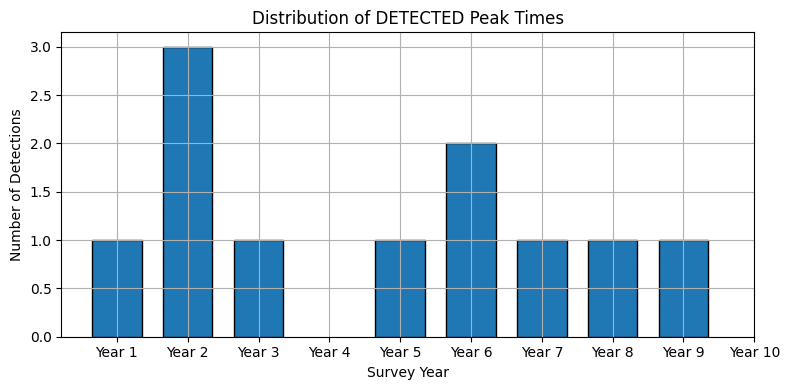

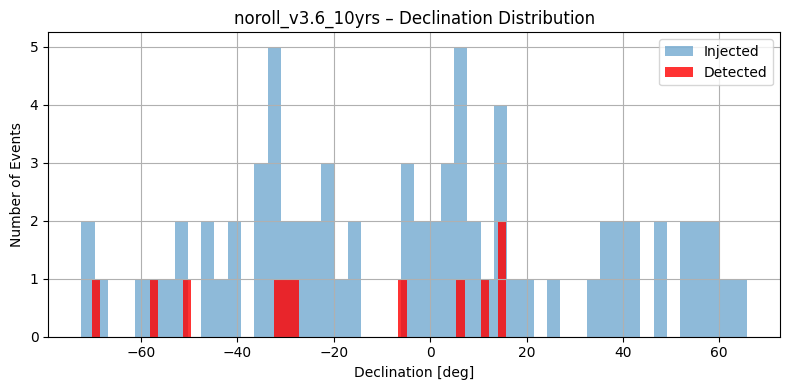

In [9]:
#run detection metric
df_obs = shared_utils.run_detect(metric, slicer, cadences, shared_lc_model, db_dir, storage_dir, df_file, ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [36]:
#choose what to run in run_multi_metrics #
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=[ 'detect', 'characterize','spec_trigger'], use_extinction=use_extinction)



--- Running four_roll_v4.3.1_10yrs ---


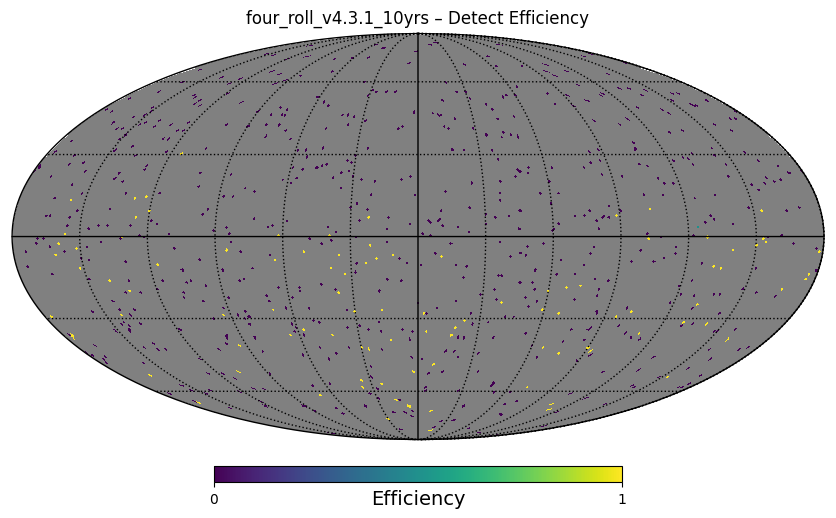

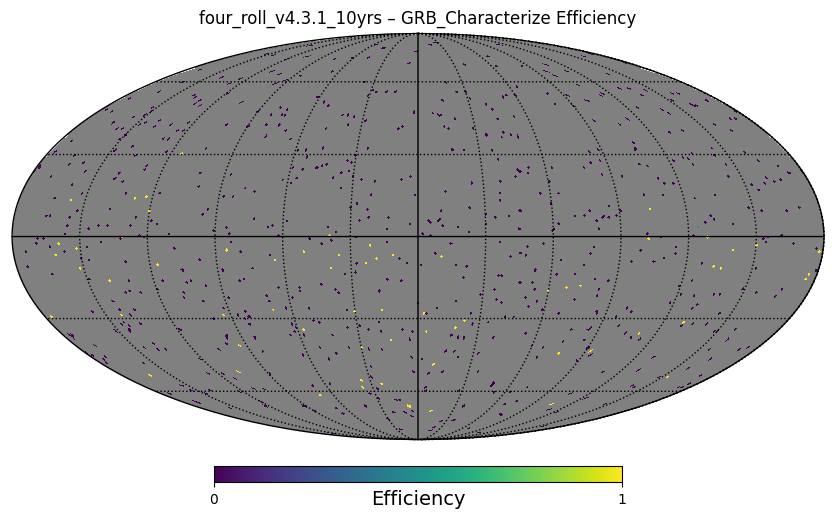

peak time  61460.34752269337
times observed at less than 21  [61471.32618221 61471.3266301 ]
peak time  61460.34752269337
times observed at less than 21  [61465.31235499 61473.30777182 61477.29338096 61491.31487098]
peak time  61460.34752269337
times observed at less than 21  [61464.30520078 61471.35069927 61471.35114688 61474.26536997
 61477.26881576]
peak time  61460.34752269337
times observed at less than 21  [61474.29092403]
peak time  61460.34752269337
times observed at less than 21  [61485.20835554 61485.23121173]
peak time  61460.34752269337
times observed at less than 21  [61465.33666566 61468.37610675 61473.33205699 61484.30608025
 61491.33901127]
peak time  63709.782040501246
times observed at less than 21  [63728.27653434 63728.27743013 63743.97781388]
peak time  63709.782040501246
times observed at less than 21  [63751.25958419]
peak time  63709.782040501246
times observed at less than 21  [63751.233241]
peak time  63709.782040501246
times observed at less than 21  [63728.3

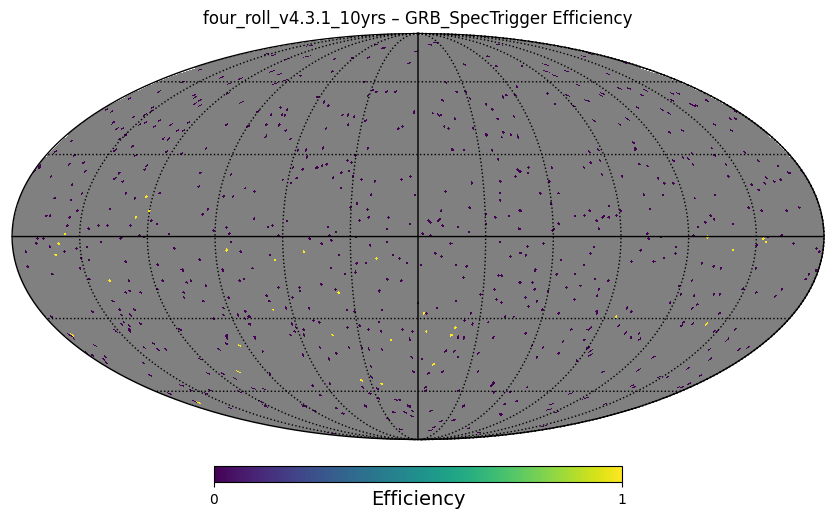

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_noroll_v3.6_10yrs

--- Running baseline_v4.3.1_10yrs ---


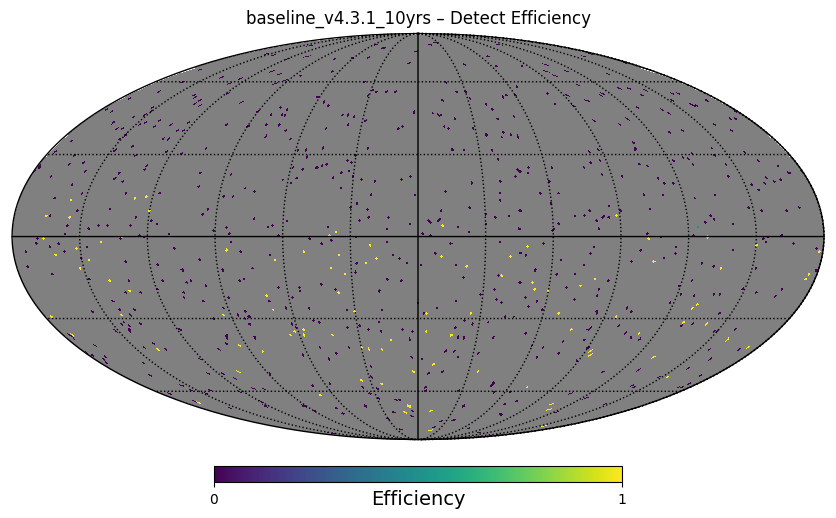

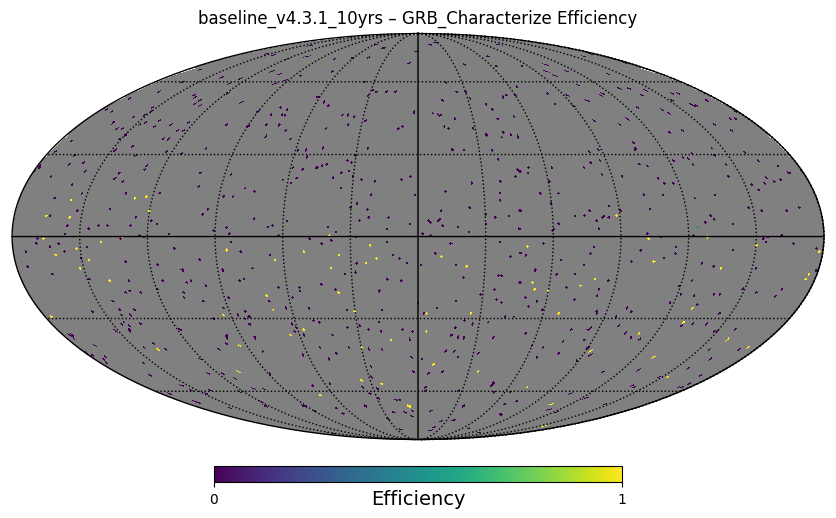

peak time  61460.34752269337
times observed at less than 21  [61465.26962876 61468.31523704 61473.25296632 61477.30461575
 61491.26549052]
peak time  61460.34752269337
times observed at less than 21  [61464.3406115  61468.29091354 61472.328109   61492.23979089
 61492.29249797 61492.29341159]
peak time  61460.34752269337
times observed at less than 21  [61482.26422133 61485.34643645 61485.3693278 ]
peak time  61460.34752269337
times observed at less than 21  [61463.3937329  61465.2937548  61473.27712342 61477.3292194
 61484.23761469 61491.28995341]
peak time  63709.782040501246
times observed at less than 21  [63721.29680798 63744.01686927 63744.01776403]
peak time  63709.782040501246
times observed at less than 21  [63719.28883996 63722.30344711 63738.30443858 63740.30611669
 63740.30656405 63741.26433757 63751.23393768]
peak time  63709.782040501246
times observed at less than 21  [63712.2930864  63721.32096046 63728.25563326 63728.25802428
 63728.25990621 63738.27979041 63741.2397516

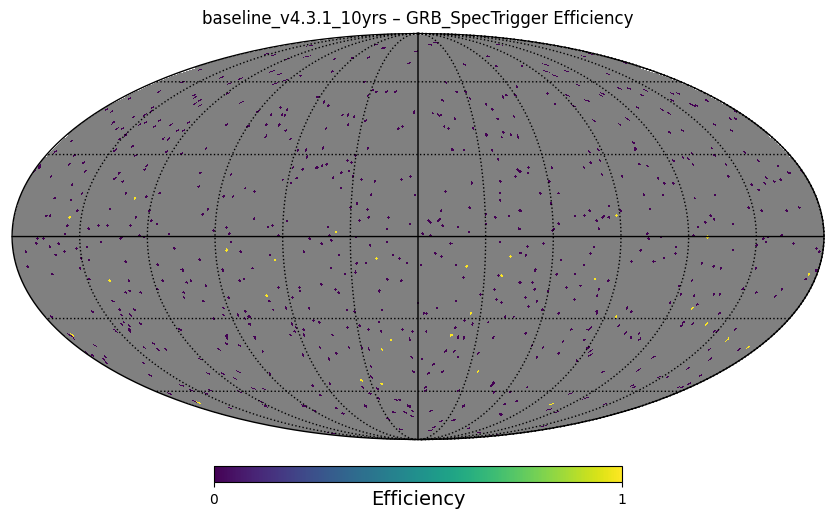

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_noroll_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
[DEBUG] Detected RA, Dec: 161.72, -6.58


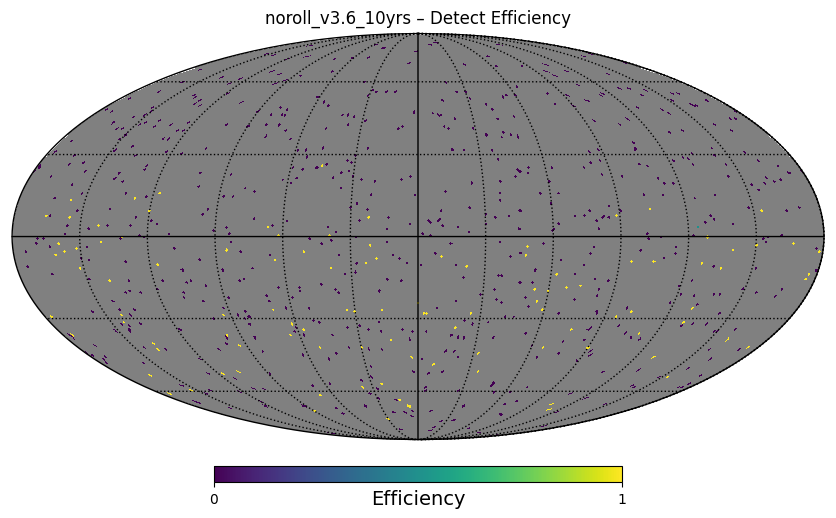

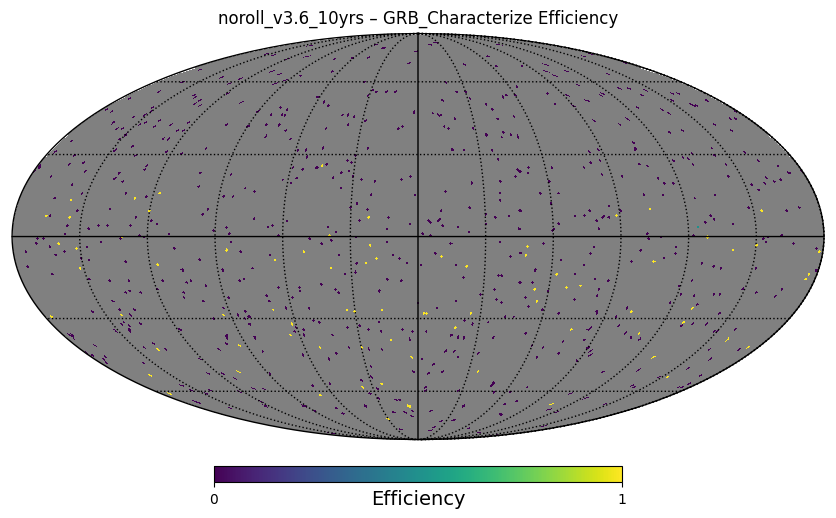

peak time  61460.34752269337
times observed at less than 21  [61476.27318862 61480.30920736]
peak time  61460.34752269337
times observed at less than 21  [61464.27905024 61469.2977598  61478.36796076 61491.31267831]
peak time  61460.34752269337
times observed at less than 21  [61464.25416886 61469.27325237 61480.33366646]
peak time  61460.34752269337
times observed at less than 21  [61463.37707204 61484.29095336 61484.31398341]
peak time  61460.34752269337
times observed at less than 21  [61463.36544939 61478.37961906 61491.33688991]
peak time  63709.782040501246
times observed at less than 21  [63714.15247275 63722.3032558  63741.25086468]
peak time  63709.782040501246
times observed at less than 21  [63712.33418575 63714.12810837 63719.15997746 63719.1720284
 63748.01224786 63748.22998596]
peak time  63709.782040501246
times observed at less than 21  [63712.30705449 63719.13288586 63719.14571833]
peak time  63709.782040501246
times observed at less than 21  [63722.32737519 63741.2264

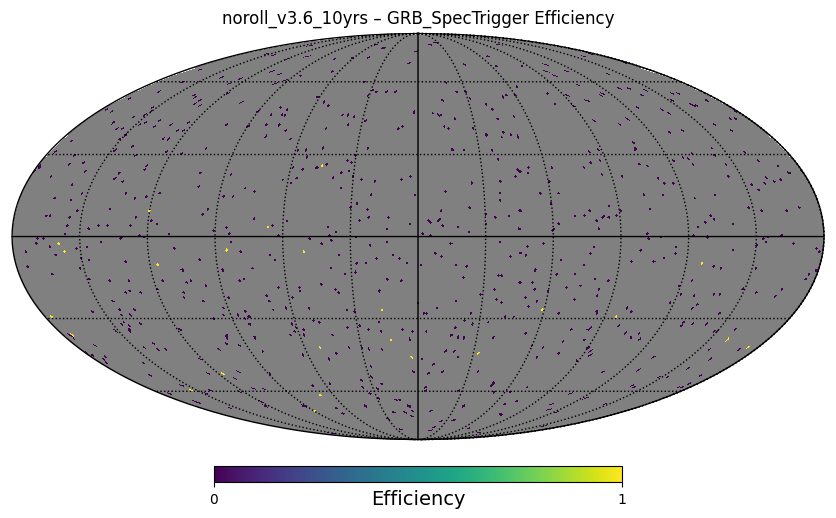

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_noroll_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_None_multi_summary.csv


In [43]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [44]:
summary_df

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,101.0,four_roll_v4.3.1_10yrs,750
four_roll_v4.3.1_10yrs_GRBAfterglowCharacterizeMetric,66.0,four_roll_v4.3.1_10yrs,750
four_roll_v4.3.1_10yrs_GRBAfterglowSpecTriggerableMetric,32.0,four_roll_v4.3.1_10yrs,750
baseline_v4.3.1_10yrs_Detect_Metric,101.0,baseline_v4.3.1_10yrs,750
baseline_v4.3.1_10yrs_GRBAfterglowCharacterizeMetric,75.0,baseline_v4.3.1_10yrs,750
baseline_v4.3.1_10yrs_GRBAfterglowSpecTriggerableMetric,30.0,baseline_v4.3.1_10yrs,750
noroll_v3.6_10yrs_Detect_Metric,108.0,noroll_v3.6_10yrs,750
noroll_v3.6_10yrs_GRBAfterglowCharacterizeMetric,79.0,noroll_v3.6_10yrs,750
noroll_v3.6_10yrs_GRBAfterglowSpecTriggerableMetric,24.0,noroll_v3.6_10yrs,750
